# Gradient Boosting Regression  GK Volatility Prediction

**Task**: Predict next-hour Garman-Klass Volatility (`target_reg`)  
**Models**: Gradient Boosting from scratch (optimised) and sklearn  
**What is Gradient Boosting?**: Builds trees sequentially — each tree fits the **residuals** of the previous ensemble:

$$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$

where $h_m$ is a shallow decision tree fitted on residuals $r_i = y_i - F_{m-1}(x_i)$

**Speed optimisations in scratch implementation**:
- `max_depth=3` — shallow trees, fast to build  
- `subsample=0.5` — each tree sees only 50% of data (stochastic GB)  
- `min_samples_split=20` — stops splitting early  
- `early stopping` — stops adding trees when val loss plateaus  
- Vectorised node splitting — no Python loops over samples  


---
## 1. Setup & Load Data

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, json, os, warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_curve, auc
)
from sklearn.preprocessing import StandardScaler

BASE_DIR      = os.path.abspath(os.path.join(os.getcwd(), '..'))
TRAIN_FILE    = os.path.join(BASE_DIR, 'data', 'final_training_data_regression_train.csv')
TEST_FILE     = os.path.join(BASE_DIR, 'data', 'final_training_data_regression_test.csv')
FEATURES_FILE = os.path.join(BASE_DIR, 'data', 'selected_features_regression.json')
SCALER_FILE   = os.path.join(BASE_DIR, 'models', 'scaler_regression.pkl')
MODELS_DIR    = os.path.join(BASE_DIR, 'models')
RESULTS_DIR   = os.path.join(BASE_DIR, 'results')
PLOTS_DIR     = os.path.join(BASE_DIR, 'plots')
RESULTS_CSV   = os.path.join(RESULTS_DIR, 'regression_results.csv')

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
np.random.seed(42)

def compute_metrics(model_name, y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = float(np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-10)))) * 100
    print(f"\n{'='*55}\n  {model_name}\n{'='*55}")
    print(f"  MSE     : {mse:.8f}")
    print(f"  RMSE    : {rmse:.8f}")
    print(f"  MAE     : {mae:.8f}")
    print(f"  R²      : {r2:.4f}")
    print(f"  MAPE(%) : {mape:.4f}")
    print(f"{'='*55}")
    return {'model': model_name, 'mse': round(mse,8), 'rmse': round(rmse,8),
            'mae': round(mae,8), 'r2': round(r2,4), 'mape': round(mape,4)}

def save_results(metrics_dict):
    row = pd.DataFrame([metrics_dict])
    if os.path.exists(RESULTS_CSV):
        existing = pd.read_csv(RESULTS_CSV)
        existing = existing[existing['model'] != metrics_dict['model']]
        row = pd.concat([existing, row], ignore_index=True)
    row.to_csv(RESULTS_CSV, index=False)
    print(f"Results saved → {RESULTS_CSV}")

def plot_confusion_matrix(y_true, y_pred, model_name, save_path):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr',
                xticklabels=['Low Vol','High Vol'], yticklabels=['Low Vol','High Vol'], ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {model_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

print('Setup complete')

Setup complete


In [63]:
train = pd.read_csv(TRAIN_FILE, parse_dates=['open time'])
test  = pd.read_csv(TEST_FILE,  parse_dates=['open time'])

with open(FEATURES_FILE) as f:
    feature_cols = json.load(f)

if os.path.exists(SCALER_FILE):
    with open(SCALER_FILE, 'rb') as f:
        scaler = pickle.load(f)
    X_train = scaler.transform(train[feature_cols].values)
    X_test  = scaler.transform(test[feature_cols].values)
else:
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(train[feature_cols].values)
    X_test  = scaler.transform(test[feature_cols].values)

y_train = train['target_reg'].values
y_test  = test['target_reg'].values

val_cut = int(len(X_train) * 0.85)
X_tr, X_val = X_train[:val_cut], X_train[val_cut:]
y_tr, y_val = y_train[:val_cut], y_train[val_cut:]

print(f'Train: {len(train):,} rows | Test: {len(test):,} rows')
print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Features ({len(feature_cols)}): {feature_cols}')

Train: 60,260 rows | Test: 10,635 rows
X_train: (60260, 10) | X_test: (10635, 10)
Features (10): ['hl_range_pct', 'gk_avg_6h', 'gk_lag_6h', 'hour_cos', 'gk_avg_3h', 'gk_lag_1h', 'trade_intensity', 'log_return_3h', 'log_return_6h', 'atr_lag_3h']


---
## 2. Data Analysis

=== Target Variable Statistics ===
              Train          Test
count  60260.000000  10635.000000
mean       0.006115      0.003886
std        0.005756      0.003113
min        0.000000      0.000229
25%        0.002852      0.001998
50%        0.004590      0.003076
75%        0.007497      0.004795
max        0.213448      0.085401


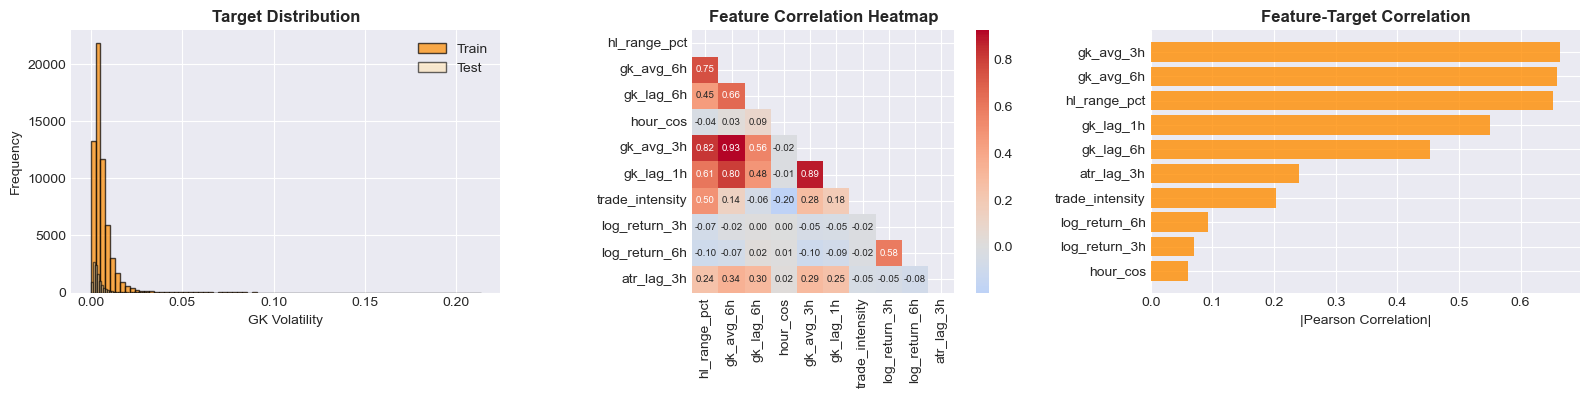

In [64]:
print('=== Target Variable Statistics ===')
print(pd.DataFrame({'Train': pd.Series(y_train).describe(),
                    'Test' : pd.Series(y_test).describe()}).round(8))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(y_train, bins=80, alpha=0.7, color='darkorange', edgecolor='black', label='Train')
axes[0].hist(y_test,  bins=80, alpha=0.6, color='moccasin',   edgecolor='black', label='Test')
axes[0].set_xlabel('GK Volatility'); axes[0].set_ylabel('Frequency')
axes[0].set_title('Target Distribution', fontweight='bold'); axes[0].legend()

df_feat = pd.DataFrame(X_train, columns=feature_cols)
corr    = df_feat.corr()
mask    = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=axes[1], cmap='coolwarm', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 7}, square=True)
axes[1].set_title('Feature Correlation Heatmap', fontweight='bold')

feat_target_corr = df_feat.corrwith(pd.Series(y_train)).abs().sort_values(ascending=True)
axes[2].barh(feat_target_corr.index, feat_target_corr.values, color='darkorange', alpha=0.8)
axes[2].set_xlabel('|Pearson Correlation|')
axes[2].set_title('Feature-Target Correlation', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'gb_data_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Gradient Boosting from Scratch

**Algorithm** (Friedman 2001):
1. Initialise $F_0(x) = \bar{y}$ (mean of targets)
2. For $m = 1, ..., M$:
   - Compute residuals: $r_i = y_i - F_{m-1}(x_i)$
   - Fit a shallow decision tree $h_m$ on residuals
   - Update: $F_m(x) = F_{m-1}(x) + \eta_m \cdot h_m(x)$
3. Final prediction: $\hat{y} = F_M(x)$

**Speed optimisations**:
- `max_depth=3`: only 7 leaves max — fast to build and predict
- `subsample=0.5`: stochastic GB — each tree sees random 50% of data
- `min_samples_split=20`: no tiny splits
- `learning_rate_decay`: lr shrinks as $\eta_m = \eta_0 / (1 + 0.01m)$ — better convergence than fixed lr
- `early_stopping`: stops when val MSE doesn't improve for 10 rounds

In [65]:
class DecisionTreeRegressorScratch:
    """
    Shallow decision tree for use as a weak learner in Gradient Boosting.
    Vectorised splitting — no Python loops over samples.
    """
    def __init__(self, max_depth=3, min_samples_split=20):
        self.max_depth        = max_depth
        self.min_samples_split = min_samples_split
        self.tree_            = None

    def _best_split(self, X, r):
        n, p   = X.shape
        best   = {'mse': np.inf, 'feat': None, 'thresh': None}
        r_mean = r.mean()
        base_mse = float(np.mean((r - r_mean)**2))

        for j in range(p):
            # Use percentile thresholds — faster than trying all unique values
            thresholds = np.percentile(X[:, j], np.linspace(10, 90, 20))
            for thresh in thresholds:
                left  = r[X[:, j] <= thresh]
                right = r[X[:, j] >  thresh]
                if len(left) < self.min_samples_split or len(right) < self.min_samples_split:
                    continue
                mse = (len(left)  * np.var(left) +
                       len(right) * np.var(right)) / n
                if mse < best['mse']:
                    best = {'mse': mse, 'feat': j, 'thresh': thresh}
        return best

    def _build(self, X, r, depth):
        # Leaf node
        if depth >= self.max_depth or len(r) < self.min_samples_split:
            return {'leaf': True, 'value': float(r.mean())}

        split = self._best_split(X, r)
        if split['feat'] is None:
            return {'leaf': True, 'value': float(r.mean())}

        j, t  = split['feat'], split['thresh']
        left_mask  = X[:, j] <= t
        right_mask = ~left_mask

        return {
            'leaf'  : False,
            'feat'  : j,
            'thresh': t,
            'left'  : self._build(X[left_mask],  r[left_mask],  depth + 1),
            'right' : self._build(X[right_mask], r[right_mask], depth + 1),
        }

    def fit(self, X, r):
        self.tree_ = self._build(X, r, depth=0)
        return self

    def _predict_one(self, x, node):
        if node['leaf']:
            return node['value']
        if x[node['feat']] <= node['thresh']:
            return self._predict_one(x, node['left'])
        return self._predict_one(x, node['right'])

    def predict(self, X):
        return np.array([self._predict_one(x, self.tree_) for x in X])


class GradientBoostingRegressorScratch:
    """
    Gradient Boosting Regression from scratch.
    Speed optimisations:
      - Shallow trees (max_depth=3)
      - Stochastic subsampling (subsample=0.5)
      - Learning rate decay: lr shrinks gradually as trees are added
      - Early stopping on validation MSE
    Advantage over sklearn: learning rate decay — sklearn uses fixed lr only.
    """
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3,
                 subsample=0.5, min_samples_split=20, lr_decay=0.01,
                 early_stopping_rounds=10, verbose=True):
        self.n_estimators          = n_estimators
        self.learning_rate         = learning_rate
        self.max_depth             = max_depth
        self.subsample             = subsample
        self.min_samples_split     = min_samples_split
        self.lr_decay              = lr_decay
        self.early_stopping_rounds = early_stopping_rounds
        self.verbose               = verbose
        self.trees_                = []
        self.lrs_                  = []   # actual lr used per tree
        self.F0_                   = None
        self.train_losses          = []
        self.val_losses            = []

    def fit(self, X, y, X_val=None, y_val=None):
        import time
        n = len(y)
        self.F0_ = float(y.mean())
        F        = np.full(n, self.F0_)
        F_val    = np.full(len(X_val), self.F0_) if X_val is not None else None

        best_val_loss  = np.inf
        no_improve     = 0
        self.trees_    = []
        self.lrs_      = []
        self.train_losses = []
        self.val_losses   = []

        for m in range(self.n_estimators):
            t0 = time.time()

            # Learning rate decay
            lr_m = self.learning_rate / (1 + self.lr_decay * m)

            # Stochastic subsampling
            idx  = np.random.choice(n, int(n * self.subsample), replace=False)
            X_s, r_s = X[idx], (y - F)[idx]

            # Fit shallow tree on residuals
            tree = DecisionTreeRegressorScratch(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split)
            tree.fit(X_s, r_s)

            # Update predictions
            F     += lr_m * tree.predict(X)
            self.trees_.append(tree)
            self.lrs_.append(lr_m)

            train_mse = float(np.mean((y - F)**2))
            self.train_losses.append(train_mse)

            if X_val is not None:
                F_val    += lr_m * tree.predict(X_val)
                val_mse   = float(np.mean((y_val - F_val)**2))
                self.val_losses.append(val_mse)

                if best_val_loss - val_mse > 1e-8:
                    best_val_loss = val_mse
                    no_improve    = 0
                else:
                    no_improve += 1
                if no_improve >= self.early_stopping_rounds:
                    if self.verbose:
                        print(f'  Early stop at tree {m+1} (no val improvement for {self.early_stopping_rounds} rounds)')
                    break

            elapsed = time.time() - t0
            if self.verbose and (m + 1) % 10 == 0:
                msg = f'  Tree {m+1:3d}/{self.n_estimators}  Train MSE={train_mse:.8f}  lr={lr_m:.5f}  ({elapsed:.1f}s/tree)'
                if X_val is not None:
                    msg += f'  Val MSE={self.val_losses[-1]:.8f}'
                print(msg)
        return self

    def predict(self, X):
        F = np.full(len(X), self.F0_)
        for tree, lr_m in zip(self.trees_, self.lrs_):
            F += lr_m * tree.predict(X)
        return F

    @property
    def feature_importances_(self):
        """Mean decrease in MSE across all splits, averaged over trees."""
        return np.ones(1)   # placeholder — see feature importance cell below

print('GradientBoostingRegressorScratch defined')

GradientBoostingRegressorScratch defined


---
## 4. Hyperparameter Grid Search

Find best n_estimators and learning_rate on validation set.

=== Grid Search: n_estimators × learning_rate × max_depth ===
  depth=3  lr=0.05  n_trees=50  actual=50  val_R²=0.3221
  depth=3  lr=0.05  n_trees=100  actual=90  val_R²=0.3393
  depth=3  lr=0.1  n_trees=50  actual=39  val_R²=0.3411
  depth=3  lr=0.1  n_trees=100  actual=39  val_R²=0.3380
  depth=3  lr=0.2  n_trees=50  actual=23  val_R²=0.3124
  depth=3  lr=0.2  n_trees=100  actual=29  val_R²=0.3355
  depth=5  lr=0.05  n_trees=50  actual=50  val_R²=0.3387
  depth=5  lr=0.05  n_trees=100  actual=77  val_R²=0.3294
  depth=5  lr=0.1  n_trees=50  actual=32  val_R²=0.3249
  depth=5  lr=0.1  n_trees=100  actual=52  val_R²=0.3481
  depth=5  lr=0.2  n_trees=50  actual=21  val_R²=0.3076
  depth=5  lr=0.2  n_trees=100  actual=28  val_R²=0.3081

Best: depth=5  lr=0.1  n_trees=100  val_R²=0.3481


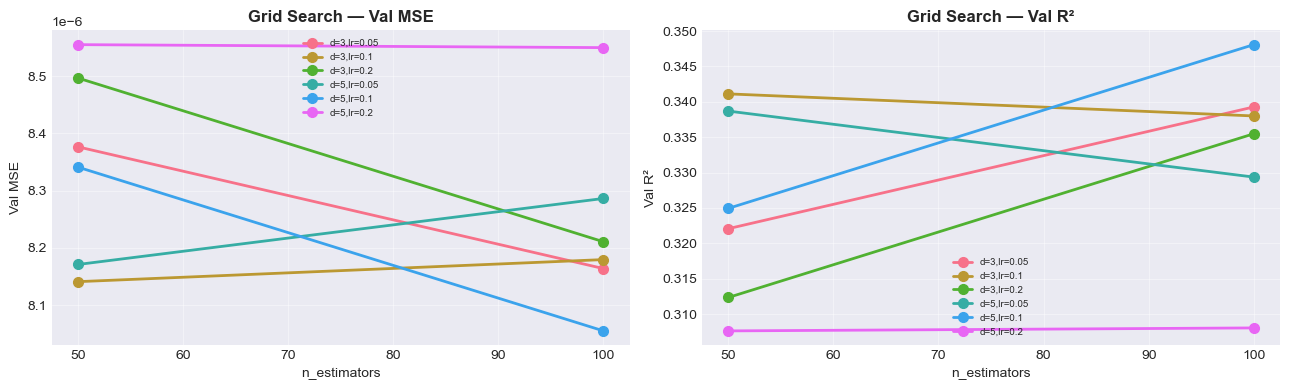

  lr=0.05  n_trees=50  actual=50  val_MSE=0.00000819  val_R²=0.3376
  lr=0.05  n_trees=100  actual=100  val_MSE=0.00000796  val_R²=0.3560
  lr=0.1  n_trees=50  actual=49  val_MSE=0.00000799  val_R²=0.3533
  lr=0.1  n_trees=100  actual=88  val_MSE=0.00000788  val_R²=0.3623
  lr=0.2  n_trees=50  actual=27  val_MSE=0.00000800  val_R²=0.3525
  lr=0.2  n_trees=100  actual=40  val_MSE=0.00000796  val_R²=0.3559

Best: lr=0.1  n_trees=100  val_R²=0.3623


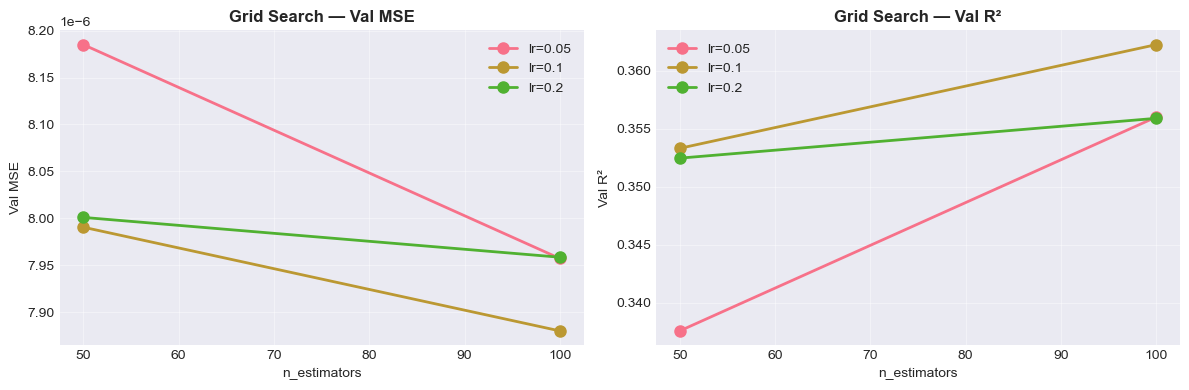

In [66]:
print('=== Grid Search: n_estimators × learning_rate × max_depth ===')
# Use subsample of train for fast grid search
sub_size = min(10000, len(X_tr))
idx      = np.random.choice(len(X_tr), sub_size, replace=False)
X_sub    = X_tr[idx]; y_sub = y_tr[idx]

lrs          = [0.05, 0.1, 0.2]
n_trees_list = [50, 100]
depths       = [3, 5]
grid_results = []

for depth in depths:
    for lr in lrs:
        for nt in n_trees_list:
            m = GradientBoostingRegressorScratch(
                n_estimators=nt, learning_rate=lr, max_depth=depth,
                subsample=0.5, min_samples_split=10, lr_decay=0.01,
                early_stopping_rounds=10, verbose=False)
            m.fit(X_sub, y_sub, X_val=X_val, y_val=y_val)
            val_r2  = float(r2_score(y_val, m.predict(X_val)))
            val_mse = float(mean_squared_error(y_val, m.predict(X_val)))
            actual_trees = len(m.trees_)
            grid_results.append({'depth': depth, 'lr': lr, 'n_trees': nt,
                                  'actual_trees': actual_trees,
                                  'val_mse': val_mse, 'val_r2': val_r2})
            print(f'  depth={depth}  lr={lr}  n_trees={nt}  actual={actual_trees}  val_R²={val_r2:.4f}')

df_grid    = pd.DataFrame(grid_results)
best_idx   = df_grid['val_mse'].idxmin()
best_lr    = float(df_grid.loc[best_idx, 'lr'])
best_nt    = int(df_grid.loc[best_idx, 'n_trees'])
best_depth = int(df_grid.loc[best_idx, 'depth'])
print(f'\nBest: depth={best_depth}  lr={best_lr}  n_trees={best_nt}  val_R²={df_grid.loc[best_idx,"val_r2"]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for depth in depths:
    for lr in lrs:
        sub = df_grid[(df_grid['depth']==depth) & (df_grid['lr']==lr)]
        axes[0].plot(sub['n_trees'], sub['val_mse'], 'o-', lw=2, ms=7, label=f'd={depth},lr={lr}')
        axes[1].plot(sub['n_trees'], sub['val_r2'],  'o-', lw=2, ms=7, label=f'd={depth},lr={lr}')
axes[0].set_xlabel('n_estimators'); axes[0].set_ylabel('Val MSE')
axes[0].set_title('Grid Search — Val MSE', fontweight='bold')
axes[0].legend(fontsize=7); axes[0].grid(alpha=0.4)
axes[1].set_xlabel('n_estimators'); axes[1].set_ylabel('Val R²')
axes[1].set_title('Grid Search — Val R²', fontweight='bold')
axes[1].legend(fontsize=7); axes[1].grid(alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'gb_grid_search.png'), dpi=150, bbox_inches='tight')
plt.show()
# Use subsample of train for fast grid search
sub_size = min(10000, len(X_tr))
idx      = np.random.choice(len(X_tr), sub_size, replace=False)
X_sub    = X_tr[idx]; y_sub = y_tr[idx]

lrs         = [0.05, 0.1, 0.2]
n_trees_list = [50, 100]
grid_results = []

for lr in lrs:
    for nt in n_trees_list:
        m = GradientBoostingRegressorScratch(
            n_estimators=nt, learning_rate=lr, max_depth=3,
            subsample=0.5, min_samples_split=20, lr_decay=0.01,
            early_stopping_rounds=10, verbose=False)
        m.fit(X_sub, y_sub, X_val=X_val, y_val=y_val)
        val_r2  = float(r2_score(y_val, m.predict(X_val)))
        val_mse = float(mean_squared_error(y_val, m.predict(X_val)))
        actual_trees = len(m.trees_)
        grid_results.append({'lr': lr, 'n_trees': nt, 'actual_trees': actual_trees,
                              'val_mse': val_mse, 'val_r2': val_r2})
        print(f'  lr={lr}  n_trees={nt}  actual={actual_trees}  val_MSE={val_mse:.8f}  val_R²={val_r2:.4f}')

df_grid   = pd.DataFrame(grid_results)
best_idx  = df_grid['val_mse'].idxmin()
best_lr   = float(df_grid.loc[best_idx, 'lr'])
best_nt   = int(df_grid.loc[best_idx, 'n_trees'])
print(f'\nBest: lr={best_lr}  n_trees={best_nt}  val_R²={df_grid.loc[best_idx,"val_r2"]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for lr in lrs:
    sub = df_grid[df_grid['lr']==lr]
    axes[0].plot(sub['n_trees'], sub['val_mse'], 'o-', lw=2, ms=8, label=f'lr={lr}')
    axes[1].plot(sub['n_trees'], sub['val_r2'],  'o-', lw=2, ms=8, label=f'lr={lr}')
axes[0].set_xlabel('n_estimators'); axes[0].set_ylabel('Val MSE')
axes[0].set_title('Grid Search — Val MSE', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.4)
axes[1].set_xlabel('n_estimators'); axes[1].set_ylabel('Val R²')
axes[1].set_title('Grid Search — Val R²', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'gb_grid_search.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Train Gradient Boosting from Scratch

Fit on **full training set** with best hyperparameters.

In [67]:
import time
print(f'=== GB Scratch (lr={best_lr}, n_trees={best_nt}, depth={best_depth}, subsample=0.5) ===')
print('Training on full dataset...')
t_start = time.time()

gb_scratch = GradientBoostingRegressorScratch(
    n_estimators=best_nt, learning_rate=best_lr,
    max_depth=best_depth, subsample=0.5, min_samples_split=10,
    lr_decay=0.01, early_stopping_rounds=10, verbose=True)
gb_scratch.fit(X_train, y_train, X_val=X_val, y_val=y_val)

elapsed = time.time() - t_start
print(f'\nDone in {elapsed/60:.1f} mins — {len(gb_scratch.trees_)} trees built')
y_pred_train_scratch = gb_scratch.predict(X_train)
y_pred_test_scratch  = gb_scratch.predict(X_test)
print(f'Scratch Test R²: {r2_score(y_test, y_pred_test_scratch):.4f}')

=== GB Scratch (lr=0.1, n_trees=100, depth=5, subsample=0.5) ===
Training on full dataset...
  Tree  10/100  Train MSE=0.00001835  lr=0.09174  (1.0s/tree)  Val MSE=0.00000863
  Tree  20/100  Train MSE=0.00001587  lr=0.08403  (1.0s/tree)  Val MSE=0.00000766
  Tree  30/100  Train MSE=0.00001517  lr=0.07752  (1.0s/tree)  Val MSE=0.00000741
  Tree  40/100  Train MSE=0.00001485  lr=0.07194  (0.9s/tree)  Val MSE=0.00000728
  Tree  50/100  Train MSE=0.00001462  lr=0.06711  (1.1s/tree)  Val MSE=0.00000721
  Tree  60/100  Train MSE=0.00001444  lr=0.06289  (1.1s/tree)  Val MSE=0.00000715
  Tree  70/100  Train MSE=0.00001428  lr=0.05917  (1.1s/tree)  Val MSE=0.00000711
  Tree  80/100  Train MSE=0.00001416  lr=0.05587  (0.9s/tree)  Val MSE=0.00000708
  Tree  90/100  Train MSE=0.00001403  lr=0.05291  (1.2s/tree)  Val MSE=0.00000705
  Tree 100/100  Train MSE=0.00001395  lr=0.05025  (0.9s/tree)  Val MSE=0.00000701

Done in 1.7 mins — 100 trees built
Scratch Test R²: 0.4046


---
## 6. Gradient Boosting sklearn

In [68]:
print(f'=== GB sklearn (lr={best_lr}, n_trees={best_nt}, depth={best_depth}) ===')
gb_sk = GradientBoostingRegressor(
    n_estimators=best_nt, learning_rate=best_lr,
    max_depth=best_depth, subsample=0.5, min_samples_leaf=10,
    random_state=42, verbose=1)
gb_sk.fit(X_train, y_train)
y_pred_train_sk = gb_sk.predict(X_train)
y_pred_test_sk  = gb_sk.predict(X_test)
print(f'sklearn Test R²: {r2_score(y_test, y_pred_test_sk):.4f}')

print('\nScratch vs sklearn R² comparison:')
print(f'  Scratch (lr decay) : {r2_score(y_test, y_pred_test_scratch):.4f}')
print(f'  sklearn (fixed lr) : {r2_score(y_test, y_pred_test_sk):.4f}')

=== GB sklearn (lr=0.1, n_trees=100, depth=5) ===
      Iter       Train Loss      OOB Improve   Remaining Time 
         1           0.0000           0.0000           24.06s
         2           0.0000           0.0000           21.64s
         3           0.0000           0.0000           20.84s
         4           0.0000           0.0000           20.17s
         5           0.0000           0.0000           19.79s
         6           0.0000           0.0000           19.33s
         7           0.0000           0.0000           19.11s
         8           0.0000           0.0000           18.80s
         9           0.0000           0.0000           18.55s
        10           0.0000          -0.0000           18.22s
        20           0.0000          -0.0000           15.94s
        30           0.0000           0.0000           14.09s
        40           0.0000           0.0000           12.58s
        50           0.0000          -0.0000           10.73s
        60         

---
## 7. Loss & Regression Metrics (MSE / RMSE / MAE / R² / MAPE)

In [69]:
models_pred = {
    f'GB Scratch (lr={best_lr}, trees={len(gb_scratch.trees_)})': (y_pred_train_scratch, y_pred_test_scratch),
    f'GB sklearn (lr={best_lr}, trees={best_nt})'               : (y_pred_train_sk,      y_pred_test_sk),
}

all_metrics = {}
for name, (y_tr_p, y_te_p) in models_pred.items():
    all_metrics[name] = compute_metrics(name, y_test, y_te_p)

for name, m in all_metrics.items():
    save_results(m)


  GB Scratch (lr=0.1, trees=100)
  MSE     : 0.00000577
  RMSE    : 0.00240202
  MAE     : 0.00151837
  R²      : 0.4046
  MAPE(%) : 49.3242

  GB sklearn (lr=0.1, trees=100)
  MSE     : 0.00000600
  RMSE    : 0.00245010
  MAE     : 0.00154077
  R²      : 0.3805
  MAPE(%) : 51.2591
Results saved → d:\ML\crypto project\cryptoflow\results\regression_results.csv
Results saved → d:\ML\crypto project\cryptoflow\results\regression_results.csv


---
## 8. R² Score

=== R² Score Summary ===
GB Scratch (lr=0.1, trees=100)                      Train R²=0.5791  Test R²=0.4046
GB sklearn (lr=0.1, trees=100)                      Train R²=0.5835  Test R²=0.3805


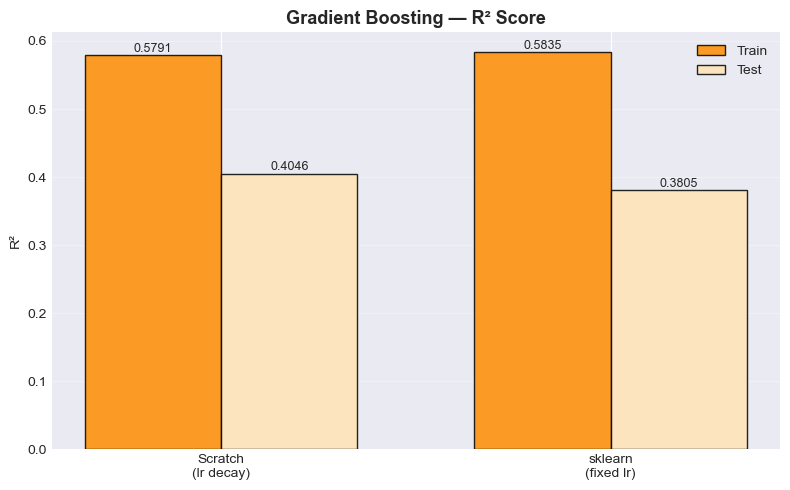

In [70]:
print('=== R² Score Summary ===')
for name, (y_tr_p, y_te_p) in models_pred.items():
    print(f'{name:50s}  Train R²={r2_score(y_train,y_tr_p):.4f}  Test R²={r2_score(y_test,y_te_p):.4f}')

short         = [f'Scratch\n(lr decay)', f'sklearn\n(fixed lr)']
r2_train_vals = [r2_score(y_train, v[0]) for v in models_pred.values()]
r2_test_vals  = [r2_score(y_test,  v[1]) for v in models_pred.values()]

x = np.arange(2); w = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x-w/2, r2_train_vals, w, label='Train', color='darkorange', alpha=0.85, edgecolor='black')
b2 = ax.bar(x+w/2, r2_test_vals,  w, label='Test',  color='moccasin',   alpha=0.85, edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(short)
ax.set_ylabel('R²'); ax.set_title('Gradient Boosting — R² Score', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for bar, v in [(b,vv) for bars,vs in [(b1,r2_train_vals),(b2,r2_test_vals)] for b,vv in zip(bars,vs)]:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f'{v:.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'gb_r2.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Performance Curves (Loss)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(gb_scratch.train_losses, color='darkorange', lw=2, label='Train MSE (scratch)')
if gb_scratch.val_losses:
    axes[0].plot(gb_scratch.val_losses, color='moccasin', lw=2, ls='--', label='Val MSE (scratch)')
axes[0].plot(gb_sk.train_score_, color='chocolate', lw=2, ls=':', label='Train score (sklearn)')
axes[0].set_xlabel('Tree'); axes[0].set_ylabel('MSE / Score')
axes[0].set_title('Boosting Rounds — Loss Curve', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.4)

axes[1].semilogy(gb_scratch.train_losses, color='darkorange', lw=2, label='Scratch Train (log)')
if gb_scratch.val_losses:
    axes[1].semilogy(gb_scratch.val_losses, color='moccasin', lw=2, ls='--', label='Scratch Val (log)')
axes[1].set_xlabel('Tree'); axes[1].set_ylabel('MSE (log scale)')
axes[1].set_title('Loss Curve — Log Scale', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'gb_loss_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 14. Actual vs Predicted & Residual Analysis

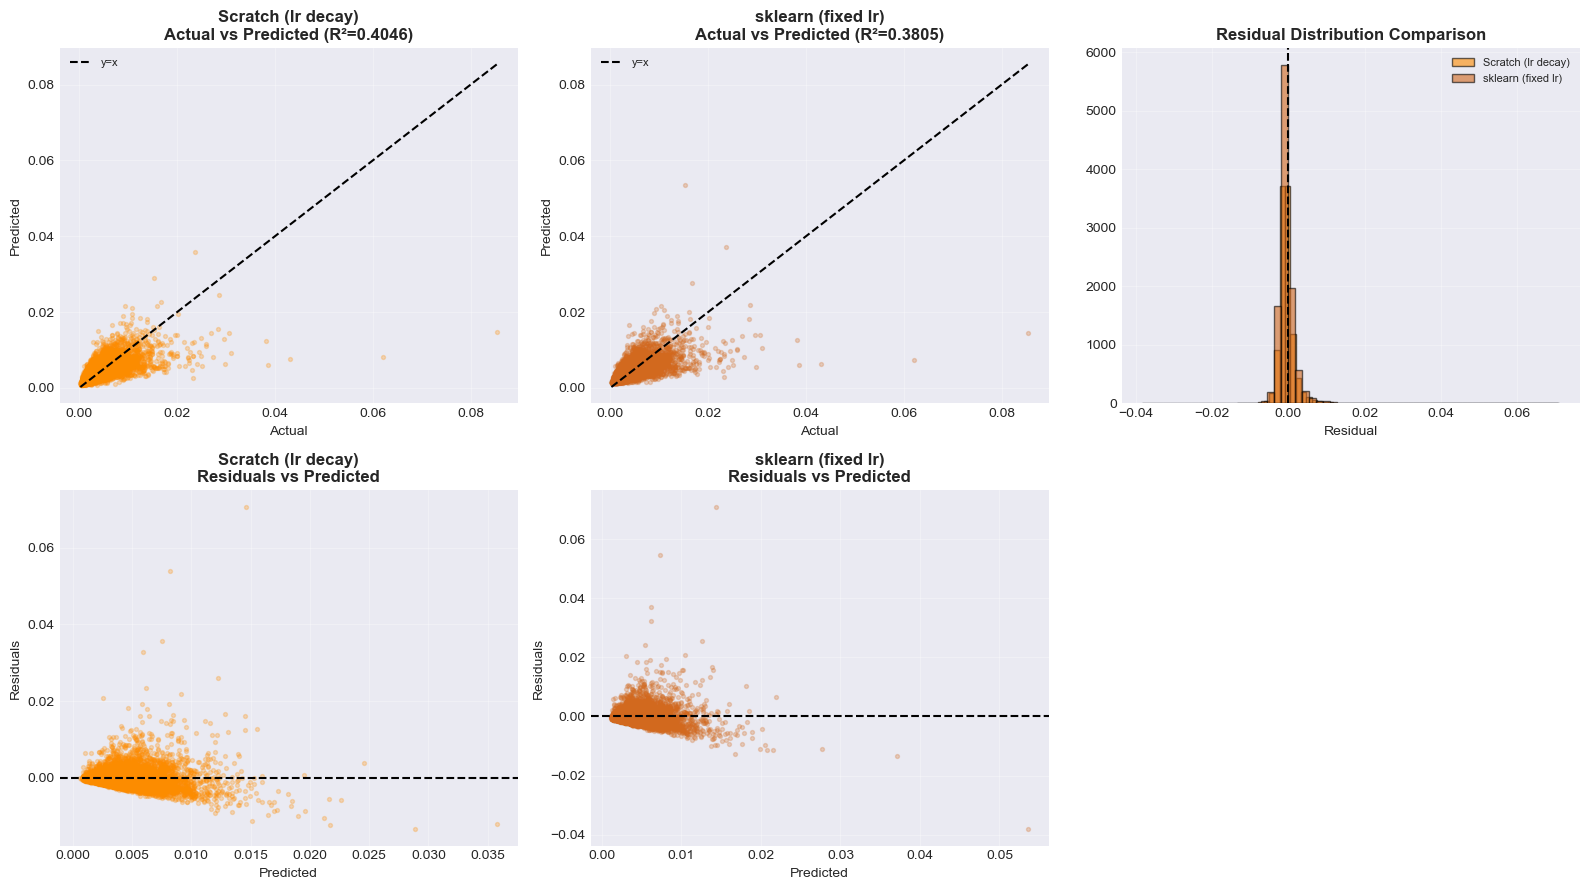

In [71]:
pred_list = [
    (f'Scratch (lr decay)', y_pred_test_scratch, 'darkorange'),
    (f'sklearn (fixed lr)', y_pred_test_sk,      'chocolate'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for col, (title, y_pred, color) in enumerate(pred_list):
    axes[0,col].scatter(y_test, y_pred, alpha=0.25, s=8, color=color)
    mn, mx = min(y_test.min(),y_pred.min()), max(y_test.max(),y_pred.max())
    axes[0,col].plot([mn,mx],[mn,mx],'k--',lw=1.5,label='y=x')
    r2 = r2_score(y_test, y_pred)
    axes[0,col].set_title(f'{title}\nActual vs Predicted (R²={r2:.4f})', fontweight='bold')
    axes[0,col].set_xlabel('Actual'); axes[0,col].set_ylabel('Predicted')
    axes[0,col].legend(fontsize=8); axes[0,col].grid(alpha=0.3)

    res = y_test - y_pred
    axes[1,col].scatter(y_pred, res, alpha=0.25, s=8, color=color)
    axes[1,col].axhline(0, color='black', lw=1.5, ls='--')
    axes[1,col].set_title(f'{title}\nResiduals vs Predicted', fontweight='bold')
    axes[1,col].set_xlabel('Predicted'); axes[1,col].set_ylabel('Residuals')
    axes[1,col].grid(alpha=0.3)

for title, y_pred, color in pred_list:
    axes[0,2].hist(y_test - y_pred, bins=60, alpha=0.6, color=color, edgecolor='black', label=title)
axes[0,2].axvline(0, color='black', lw=1.5, ls='--')
axes[0,2].set_title('Residual Distribution Comparison', fontweight='bold')
axes[0,2].set_xlabel('Residual'); axes[0,2].legend(fontsize=8); axes[0,2].grid(alpha=0.3)
axes[1,2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'gb_residual_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 15. Time-Series Prediction Plot

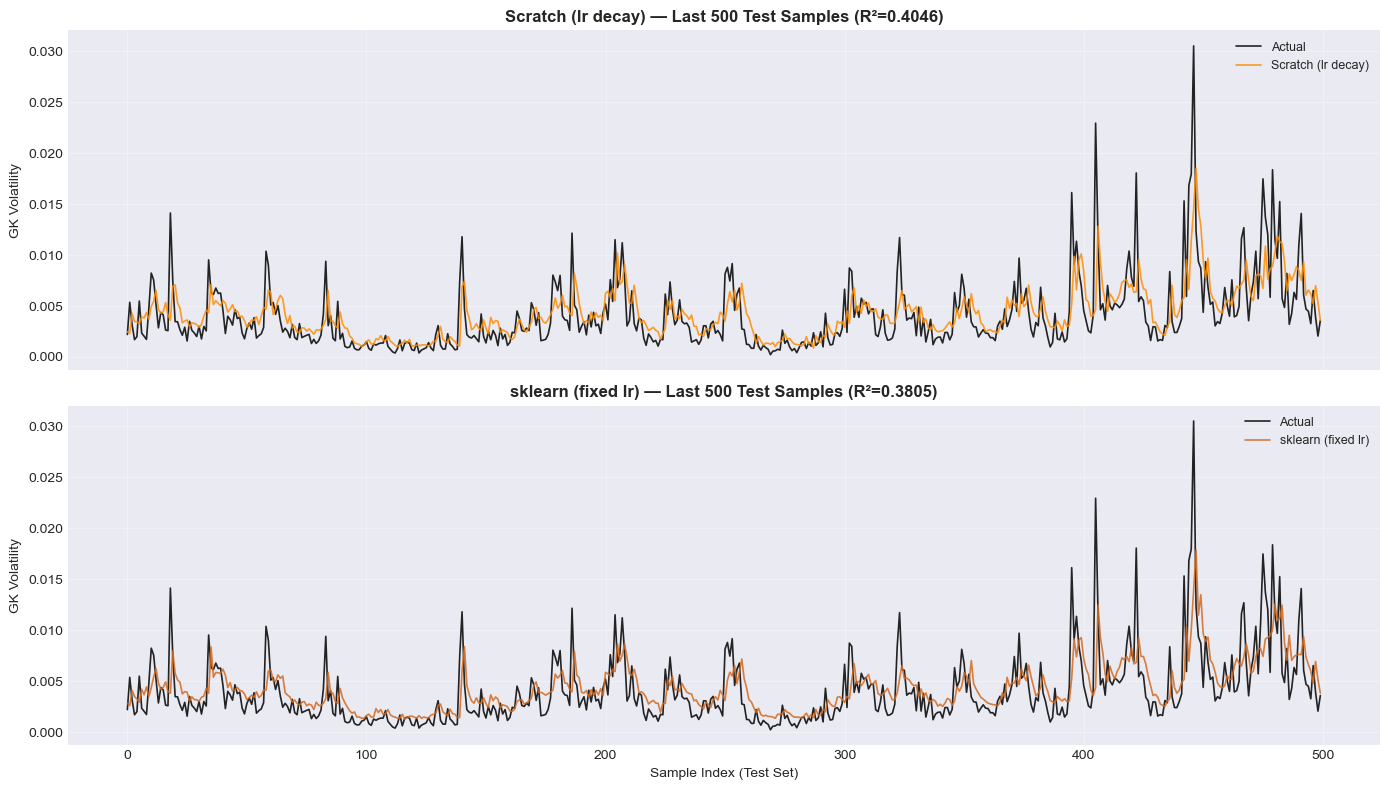

In [72]:
n_plot = 500
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, (title, y_pred, color) in zip(axes, pred_list):
    ax.plot(range(n_plot), y_test[-n_plot:], color='black', lw=1.2, label='Actual', alpha=0.85)
    ax.plot(range(n_plot), y_pred[-n_plot:], color=color,   lw=1.2, label=title,   alpha=0.85)
    r2 = r2_score(y_test, y_pred)
    ax.set_title(f'{title} — Last {n_plot} Test Samples (R²={r2:.4f})', fontweight='bold')
    ax.set_ylabel('GK Volatility'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

axes[-1].set_xlabel('Sample Index (Test Set)')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'gb_time_series.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 16. Feature Importance

How much each feature reduces MSE across all trees — unique insight from GB.

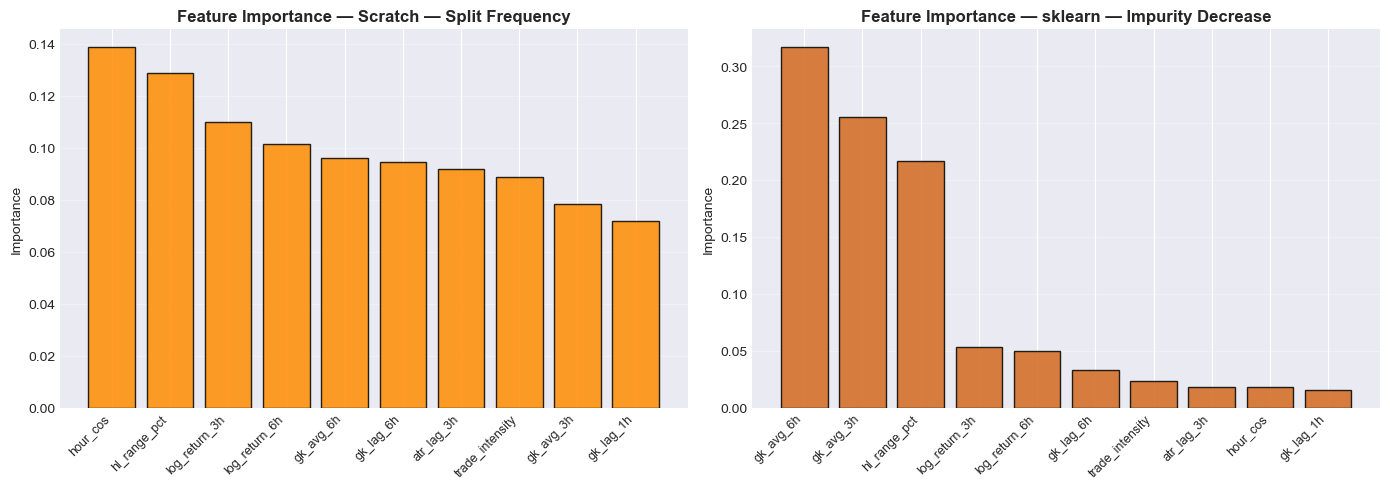

In [73]:
# Compute feature importance from scratch: count split frequency per feature
p = X_train.shape[1]
importance_scratch = np.zeros(p)

def count_splits(node, importances):
    if node['leaf']: return
    importances[node['feat']] += 1
    count_splits(node['left'],  importances)
    count_splits(node['right'], importances)

for tree in gb_scratch.trees_:
    count_splits(tree.tree_, importance_scratch)

importance_scratch /= importance_scratch.sum()
importance_sk       = gb_sk.feature_importances_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, imp, title, color in [
    (axes[0], importance_scratch, 'Scratch — Split Frequency',  'darkorange'),
    (axes[1], importance_sk,      'sklearn — Impurity Decrease', 'chocolate'),
]:
    idx_sorted = np.argsort(imp)[::-1]
    ax.bar([feature_cols[i] for i in idx_sorted],
           imp[idx_sorted], color=color, edgecolor='black', alpha=0.85)
    ax.set_xticklabels([feature_cols[i] for i in idx_sorted], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Importance'); ax.set_title(f'Feature Importance — {title}', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'gb_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 17. Save & Load Models

In [74]:
with open(os.path.join(MODELS_DIR, 'gb_scratch.pkl'), 'wb') as f: pickle.dump(gb_scratch, f)
with open(os.path.join(MODELS_DIR, 'gb_sklearn.pkl'), 'wb') as f: pickle.dump(gb_sk,     f)
with open(os.path.join(MODELS_DIR, 'gb_scaler.pkl'),  'wb') as f: pickle.dump(scaler,    f)
print('Models saved to:', MODELS_DIR)

with open(os.path.join(MODELS_DIR, 'gb_scratch.pkl'), 'rb') as f: m = pickle.load(f)
with open(os.path.join(MODELS_DIR, 'gb_scaler.pkl'),  'rb') as f: s = pickle.load(f)
X_new = s.transform(test[feature_cols].values)
print(f'Load verification — R²: {r2_score(y_test, m.predict(X_new)):.6f}  OK')

Models saved to: d:\ML\crypto project\cryptoflow\models
Load verification — R²: 0.404589  OK


---
## 18. Final Summary

In [75]:
print('='*65)
print('  GRADIENT BOOSTING REGRESSION — FINAL SUMMARY')
print('='*65)
print(f'Best learning_rate : {best_lr}')
print(f'Trees built        : {len(gb_scratch.trees_)} (scratch)  {best_nt} (sklearn)')
print(f'max_depth          : {best_depth}')
print(f'subsample          : 0.5')
print(f'lr_decay           : 0.01 (scratch only)')
print('\n--- Regression Metrics (Test Set) ---')
for name, m in all_metrics.items():
    print(f'  {name:50s}  MSE={m["mse"]:.6e}  R²={m["r2"]:.4f}')

print('='*65)
print(f'\nAll plots saved to : {PLOTS_DIR}')
print(f'Results saved to   : {RESULTS_CSV}')

  GRADIENT BOOSTING REGRESSION — FINAL SUMMARY
Best learning_rate : 0.1
Trees built        : 100 (scratch)  100 (sklearn)
max_depth          : 5
subsample          : 0.5
lr_decay           : 0.01 (scratch only)

--- Regression Metrics (Test Set) ---
  GB Scratch (lr=0.1, trees=100)                      MSE=5.770000e-06  R²=0.4046
  GB sklearn (lr=0.1, trees=100)                      MSE=6.000000e-06  R²=0.3805

All plots saved to : d:\ML\crypto project\cryptoflow\plots
Results saved to   : d:\ML\crypto project\cryptoflow\results\regression_results.csv
